In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots


# import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/NGC1068/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/NGC1068/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/NGC1068/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
disco_path = os.path.join(output_path, f"5672157/")
discos = {}
for filt in os.listdir(disco_path):
    disco = np.load(
        os.path.join(disco_path, filt, "discos.npy"), allow_pickle=True
    ).item()
    for key, value in disco.items():
        discos[key] = value
print(discos.keys())

dict_keys(['F480M_24', 'F480M_25', 'F430M_24', 'F430M_25', 'F380M_24', 'F380M_25'])


In [3]:
def gaussian_2d(shape, center=None, sigma=10, order=2):
    y = np.arange(shape[0])
    x = np.arange(shape[1])
    x, y = np.meshgrid(x, y)
    if center is None:
        center = (shape[1] // 2, shape[0] // 2)

    r2 = (x - center[0]) ** 2 + (y - center[1]) ** 2
    r = np.sqrt(r2)

    supergauss = np.exp(-(r**order) / (2 * sigma**order))
    return supergauss / supergauss.max()

In [4]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    # dorito.model_fits.MCAOIFit(oi_data, key, filter=key)
    dorito.model_fits.ResolvedOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in discos.items()
]
ois = ois[0:2]
for oi in ois:
    print(oi.key)

s = 113
distribution = np.ones((s, s))
distribution *= gaussian_2d((s, s), sigma=5, order=2)


model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=3.0,
)

# Initialise at the mean dirty image
otf = np.load("files/otf_support.npy")

params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
for filt in ["F380M", "F430M", "F480M"]:
    dirty_imgs = [
        oi.dirty_image(model, rotate=True, otf_support=otf)
        for oi in ois
        if oi.filter == filt
    ]

    if dirty_imgs == []:
        print(f"No dirty images for filter {filt}, skipping initialisation.")
        continue
    mean_dirty = hypot(dirty_imgs)
    # mean_dirty *= gaussian_2d((s, s), sigma=20, order=2)
    mean_dirty *= distribution
    init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-16)

for oi in ois:
    if oi.filter == filt:
        params["log_dist"][oi.get_key("log_dist")] = init_dist

model = model.set("params", params)

# model = dorito.models.MCADiscoModel(
#     ois,
#     # {"distribution": distribution, "contrast": 0.24},
#     {"distribution": distribution, "contrast": 0.525},
#     uv_npixels=2 * otf_coords.shape[-1],
#     uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
#     oversample=2.5,
#     moat_width=0,
# )

F480M_24
F480M_25
No dirty images for filter F380M, skipping initialisation.
No dirty images for filter F430M, skipping initialisation.


In [5]:
# for c in np.arange(0.2, 0.3, 0.01):
#     model = dorito.models.MCADiscoModel(
#         ois,
#         {"distribution": distribution, "contrast": c},
#         # {"distribution": distribution, "contrast": 0.525},
#         uv_npixels=2 * otf_coords.shape[-1],
#         uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
#         oversample=1.0,
#         moat_width=0,
#     )
#     print(f"Contrast: {c}", loss_fn(model, ois[0], {})[0])

In [6]:
# from scipy.ndimage import gaussian_filter

# preset = np.load("noreg_F480M.npy", allow_pickle=True).item()

# for k, log_dist in preset["log_dist"].items():
#     dist = 10**log_dist

#     dist = gaussian_filter(dist, sigma=3)
#     preset["log_dist"][k] = np.log10(dist)

# model = model.set("params", preset)

In [7]:
# fig, ax = plt.subplots(1, 3, figsize=(8, 2))

# for idx, oi in enumerate(ois):

#     init_dist = model.get_distribution(
#         oi,
#         rotate=True,
#         # with_star=False,
#     )

#     c0 = dorito.plotting.plot_result(
#         ax[idx],
#         init_dist,
#         pixel_scale=dlu.rad2arcsec(model.pscale_in),
#         cmap=inferno,
#         norm=mpl.colors.PowerNorm(0.5, vmin=0),
#     )
#     fig.colorbar(c0, ax=ax[idx])
#     ax[idx].set(title=oi.filter)

# plt.tight_layout()
# plt.show()

In [8]:
def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            dist = 10**log_dist

            # # setting edges values to zero to avoid edge effects
            # n = 5
            # dist = dist.at[-n:, :].set(1e-16)
            # dist = dist.at[:, -n:].set(1e-16)
            # dist = dist.at[:n, :].set(1e-16)
            # dist = dist.at[:, :n].set(1e-16)

            # normalising the distribution
            params["log_dist"][k] = np.log10(dist / dist.sum())

    return model_params.set("params", params), args


def MCA_normalise(model_params, args):
    params = model_params.params

    for filt in params["log_dist"].keys():

        log_dist = params["log_dist"][filt]
        contrast = params["contrast"][filt]

        dist = 10**log_dist

        # normalising the distribution
        params["log_dist"][filt] = np.log10(dist * (1 - contrast) / dist.sum())

    return model_params.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.3e}")


def phase_centre(model, oi):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    cvis = oi.to_cvis(model, distribution)
    phase = np.angle(cvis)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    posterior = dorito.stats.disco_regularised_loss_fn(model, exposure, args)[0]

    # phase centre prior
    centre = phase_centre(model, exposure)
    posterior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return posterior, ()


def grads_fn(model, grads, args):
    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    for filt in grad_params["log_dist"].keys():
        values = grad_params["log_dist"][filt]
        rand_vals = get_temperature(args) * jr.normal(key, values.shape)
        values += rand_vals

        grad_params["log_dist"][filt] = values

    # for filt in grad_params["contrast"].keys():
    #     values = grad_params["contrast"][filt]
    #     # Add the learning rate warm-up
    #     values *= get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0

    grads = grads.set("params", grad_params)
    return grads, args

In [9]:
import time
from tqdm.notebook import tqdm
from amigo.fitting import (
    Trainer,
    ModelParams,
    get_optimiser,
    get_val_grad_fn,
    get_norm_loss_fn,
    get_update_fn,
    populate_lr_model,
    ParamHistory,
)


class Train(Trainer):

    def train(
        self,
        model,
        optimisers,
        epochs,
        batches: dict,
        args={},
    ):
        # Ensure args key exists and is the right type
        args = self.check_args_key(args)

        # Get the batches and raw exposures
        batches, exposures = self.unwrap_batches(batches)

        # Get the model parameters
        model_params = ModelParams({p: model.get(p) for p in optimisers.keys()})
        lrs = populate_lr_model(self.fishers, exposures, model_params)

        # Get the optax optimiser and history bits
        optim, state = get_optimiser(model_params, optimisers)
        history = ParamHistory(model_params)

        # Get the loss and update functions
        val_grad_fn = get_val_grad_fn(self.loss_fn)
        loss_fn = get_norm_loss_fn(val_grad_fn, self.grad_fn)
        update_fn = get_update_fn(optim, self.norm_fn)

        # Looping things
        t0 = time.time()
        looper = tqdm(range(0, epochs))
        loss_dict = dict([(key, []) for key in batches.keys()])
        aux_dict = {}

        # Loop
        for epoch in looper:
            if epoch == 1:
                t1 = time.time()

            if self.args_fn is not None:
                model, args = self.args_fn(model, args, epoch)

            # Create an empty gradient model to append gradients to
            grads = model_params.map(lambda x: x * 0.0)

            # Loop over randomised batch order
            for batch_key, batch in batches.items():
                # Calculate the loss and gradients
                loss, new_grads, args, aux = loss_fn(
                    model_params, lrs, model, batch, args
                )
                grads += new_grads

                # Append the mean batch loss to the loss dictionary and update aux dict
                loss_dict[batch_key].append(loss / len(batch))

                #
                if self.aux_fn is not None:
                    aux_dict = self.aux_fn(aux_dict, aux)

                # Check for NaNs and exit if so
                if np.isnan(loss):
                    print(f"Loss is NaN on epoch {epoch}, exiting fit")
                    return self.finalise(
                        t0,
                        model,
                        loss_dict,
                        aux,
                        model_params,
                        history,
                        lrs,
                        epochs,
                        False,
                    )
                args["chi2"] = np.mean(np.array(list(aux.values())))

            # Update the regular parameters and append to history
            model_params, state, args = update_fn(grads, model_params, state, args)
            history = history.append(model_params)

            # Update the looper
            loop_fn = self.default_looper if self.looper_fn is None else self.looper_fn
            loop_fn(looper, loss_dict)

            # Print helpful things run time
            if epoch == 0:
                self.initial_print(loss_dict)
            if epoch == 1:
                self.second_print(t1, epochs)

        # Print the runtime stats and return Result object
        return self.finalise(
            t0, model, loss_dict, aux, model_params, history, lrs, epochs, True
        )


def COM(arr):
    h, w = arr.shape
    y = np.arange(h)
    x = np.arange(w)
    yy, xx = np.meshgrid(y, x, indexing="ij")  # Shape (h, w)

    total_mass = np.sum(arr)
    com_y = np.sum(yy * arr) / total_mass
    com_x = np.sum(xx * arr) / total_mass

    return np.array([com_y, com_x])


def centre_of_mass(model, oi):
    distribution = model.get_distribution(oi)
    return COM(distribution)


O = COM(init_dist)
print("Initial Centroid (y, x):", O)


def chi2(data, model, err, reduced=True):
    chi_squared = np.sum(((model - data) / err) ** 2)
    if reduced:
        dof = data.size
        return chi_squared / dof
    else:
        return chi_squared


def loss_fn(model, oi, args, width=1e-3):
    data = np.concat([oi.vis, oi.phi])
    err = np.concat([oi.d_vis, oi.d_phi])
    likelihood = chi2(data, oi(model), err)

    # return likelihood, likelihood

    # COM prior
    centre = centre_of_mass(model, oi)
    prior = -jax.scipy.stats.norm.logpdf(centre, loc=O, scale=width)

    # grabbing and exponentiating log distributions
    prior += dorito.stats.apply_regularisers(model, oi, args)

    return likelihood + prior, likelihood

Initial Centroid (y, x): [55.99851583 56.00261462]


In [10]:
# import zodiax as zdx


# def envelope(iter, A=2e2, b=4e-4, c=3.0):
#     """
#     Returns an envelope function for the given iteration.
#     The envelope is defined as A * exp(-b * iter) + c.
#     """
#     return A * np.exp(-((b * iter - c) ** 2))


# @zdx.filter_jit
# def get_temperature(args):
#     return args["chi2"] * envelope(args["t"])


# def grads_fn(model, grads, args):
#     # Get the parameters
#     grad_params = grads.params

#     # Get the key and update args with new key
#     key, subkey = jr.split(args["key"], 2)
#     args["key"] = subkey

#     for filt in grad_params["log_dist"].keys():
#         values = grad_params["log_dist"][filt]
#         rand_vals = get_temperature(args) * jr.normal(key, values.shape)
#         values *= 1 + rand_vals

#         grad_params["log_dist"][filt] = values

#     # Increment the t parameter
#     args["t"] += 1.0

#     grads = grads.set("params", grad_params)
#     return grads, args


# x = np.arange(5000)
# envs = envelope(x)


# plt.figure(figsize=(10, 3))
# plt.plot(x, envs, label="Envelope")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss vs Epochs")
# plt.grid(True)
# plt.legend()
# plt.show()

# # break

In [11]:
# n_epoch = len(x)
n_epoch = 20000
config = {
    # "contrast": sgd(1e-8, 10000),
    # "log_dist": adam(5e-2, 0, (1000, 0.1)),
    # "log_dist": adam(2e-3, 0, (1000, 0.1)),
    # "log_dist": adam(6e-4, 0),
    # "log_dist": adam(1e-3, 0, (3000, 0.1)),
    # "log_dist": adam(1e-3, 0),
    # "log_dist": adam(2e-2, 0, (1000, 0.1)),
    "log_dist": adam(5e-3, 0),
}
args = {
    "reg_dict": {
        "TV": (1e3, dorito.stats.TV),
        # "TSV": (1e6, dorito.stats.TSV),
        # "ME": (2e4, dorito.stats.ME),
    },
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "chi2": np.array(1.0),  # Initial chi-squared value
    # "n_batch": np.array(len(ois), float),  # Number of batches
    # "T0": np.array(T0),  # Initial temper/ature
    # "k": np.array(decay),  # Decay rate
    # "n_max": np.array(n_max),  # Warm-up end point
    # "min_lr": np.array(min_lr),  # Minimum warm-up learning rate
}

trainer = Trainer(
    loss_fn=centered_loss_fn,
    # loss_fn=loss_fn,
    # loss_fn=dorito.stats.regularised_loss_fn,
    # grad_fn=grads_fn,
    # norm_fn=MCA_normalise,
    norm_fn=normalise_distribution,
    # looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    # model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
)

0it [00:00, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 612,189.43
Estimated run time: 0:02:39
Full Time: 0:08:41
Final Loss: 3,827.29


[59.64678492 55.57291596]


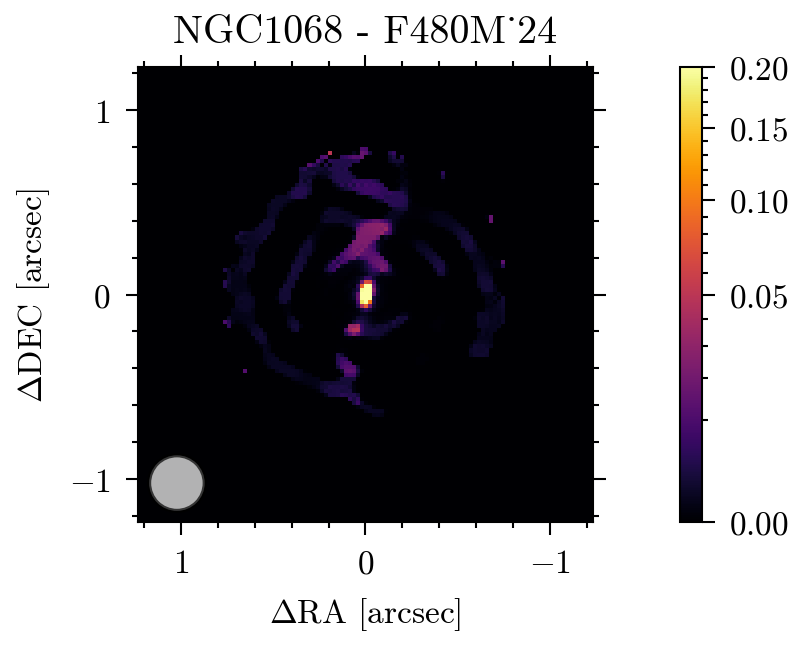

[59.64678492 55.57291596]


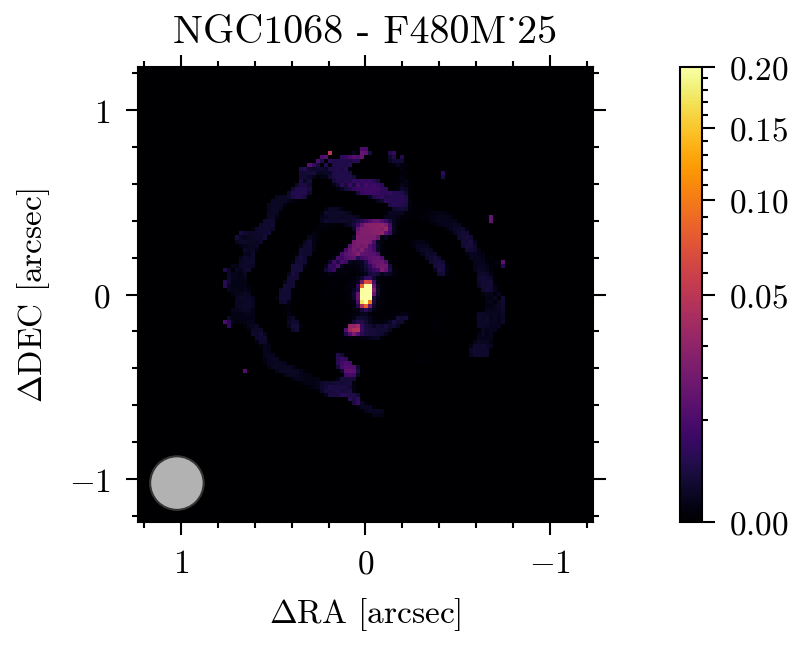

In [12]:
from amigo import plotting

for oi in ois:
    dist = result.model.get_distribution(
        oi,
        rotate=False,
        # rotate=True,
        # with_star=False,
    )
    dist /= dist.max()

    print(COM(dist))

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    # fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    # ax[0].errorbar(
    #     disco_amp,
    #     oi.vis,
    #     yerr=oi.d_vis,
    #     label="Amplitude Correlations",
    #     fmt="x",
    #     alpha=0.3,
    #     color="midnightblue",
    # )
    # x_min, x_max = ax[0].get_xlim()
    # y_min, y_max = ax[0].get_ylim()
    # min_val = min(x_min, y_min)
    # max_val = max(x_max, y_max)
    # ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    # ax[0].set_title("Amplitude Correlations")
    # ax[0].set_xlabel("Reconstructed Disco Amplitude")
    # ax[0].set_ylabel("Calibrated Disco Amplitude")
    # ax[0].legend()

    # ax[1].errorbar(
    #     disco_phase,
    #     oi.phi,
    #     yerr=oi.d_phi,
    #     label="Phase Correlations",
    #     fmt="x",
    #     alpha=0.3,
    #     color="indigo",
    # )
    # x_min, x_max = ax[1].get_xlim()
    # y_min, y_max = ax[1].get_ylim()
    # min_val = min(x_min, y_min)
    # max_val = max(x_max, y_max)
    # ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    # ax[1].set_title("Phase Correlations")
    # ax[1].set_xlabel("Reconstructed Disco Phase")
    # ax[1].set_ylabel("Calibrated Disco Phase")
    # ax[1].legend()

    # plt.tight_layout()
    # plt.show()

    # ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        # cmap="cubehelix",
        # cmap="afmhot_10u",
        # norm=mpl.colors.PowerNorm(0.1, vmin=0, vmax=500),
        norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=0.2),
        # scale=2,
        ticks=[-1, 0, 1],
        diff_lim=dlu.rad2arcsec(oi.wavel / optics_diameter),
    )

    fig.colorbar(c0)

    ax.set(title=f"NGC1068 - {oi.key}")  # , xticks=ticks, yticks=ticks)

    plt.tight_layout()
    plt.show()

# plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
# plotting.plot(result.history)

In [13]:
# l = np.array(result.losses[0])
# # l = l[::5]
# x = np.array(range(len(l)))
# envs = envelope(x)


# plt.figure(figsize=(10, 3))
# # plt.plot(x, l, label="Loss")
# plt.plot(x, envs, label="Envelope")
# plt.plot(
#     x,
#     l * envs,
#     label="Temperature",
#     linewidth=3,
# )
# # plt.yscale("log")
# # plt.ylim(0, 1.5e3)
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss vs Epochs")
# plt.grid(True)
# plt.legend()
# plt.show()

In [14]:
# break

In [15]:
import equinox as eqx
import optimistix as optx


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [
            dorito.stats.disco_regularised_loss_fn(model, exp, reg_args)[0]
            for exp in exps
        ]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        # phase centre prior
        centre = phase_centre(model, exps[0])
        centre_prior = -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=1e-3)

        return loss + sum_prior + centre_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol)
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [16]:
final_model = result.model

bfgs_model = joint_solve(
    # model,
    final_model,
    ois,
    args,
    Solver=optx.BFGS,
    # Solver=optx.LevenbergMarquardt,
    max_steps=2**14,
    rtol=1e-6,
    atol=1e-6,
)

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

No exposures for filter F380M, skipping initialisation.
No exposures for filter F430M, skipping initialisation.
F480M_24
F480M_25
Initial loss: 40819.666183740585
Final loss: 3703.6652639298454
16384 8340
The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.



In [17]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

In [18]:
# np.save("noreg_F480M.npy", bfgs_model.params, allow_pickle=True)

0.9999999428441586
Loss: 2.166e+03


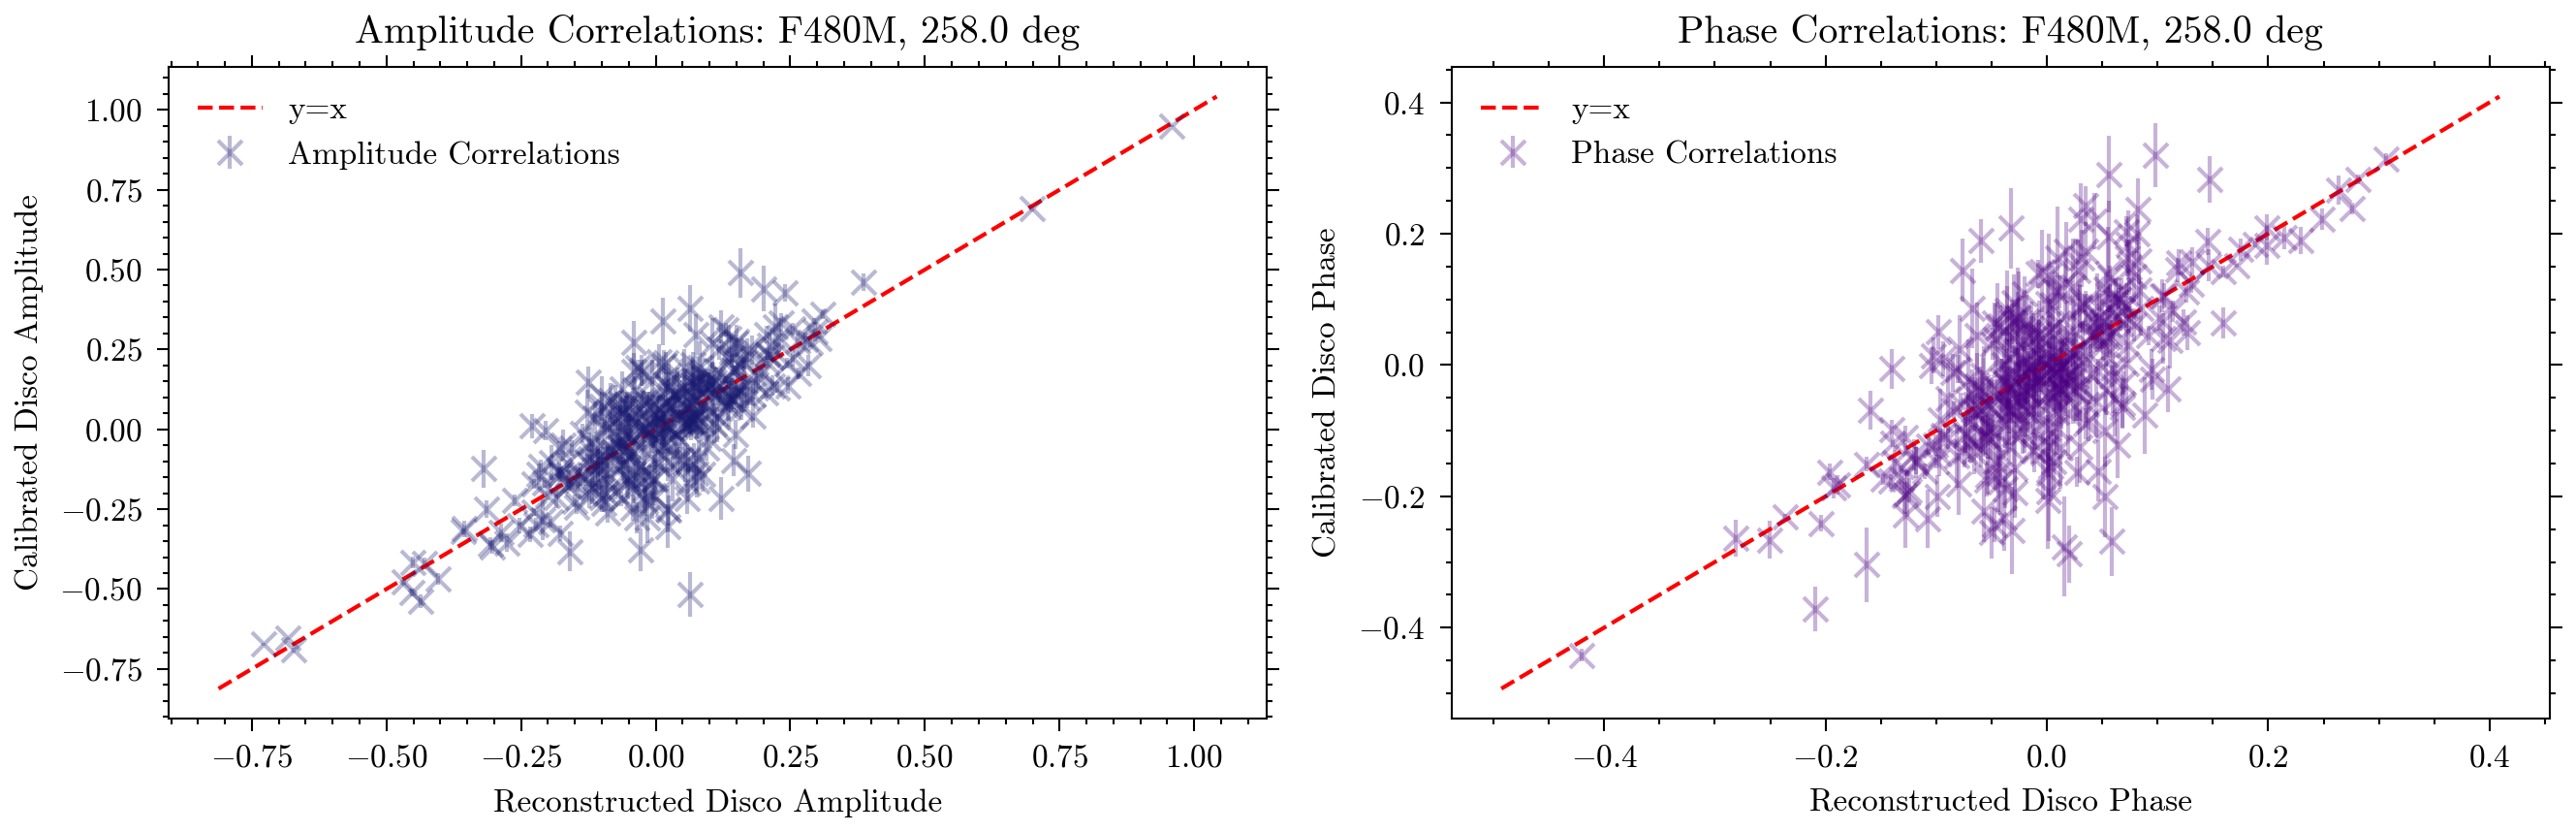

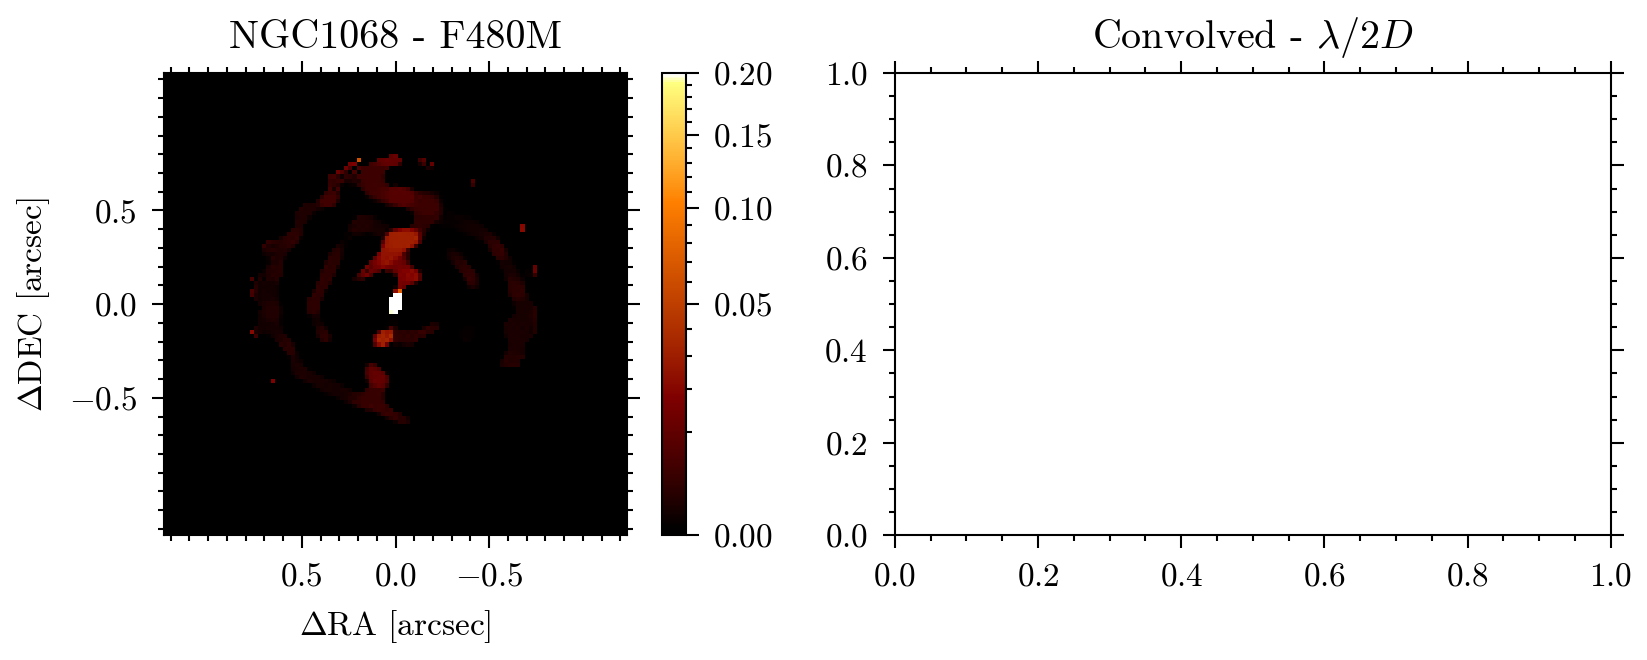

0.9981201281933705
Loss: 5.274e+03


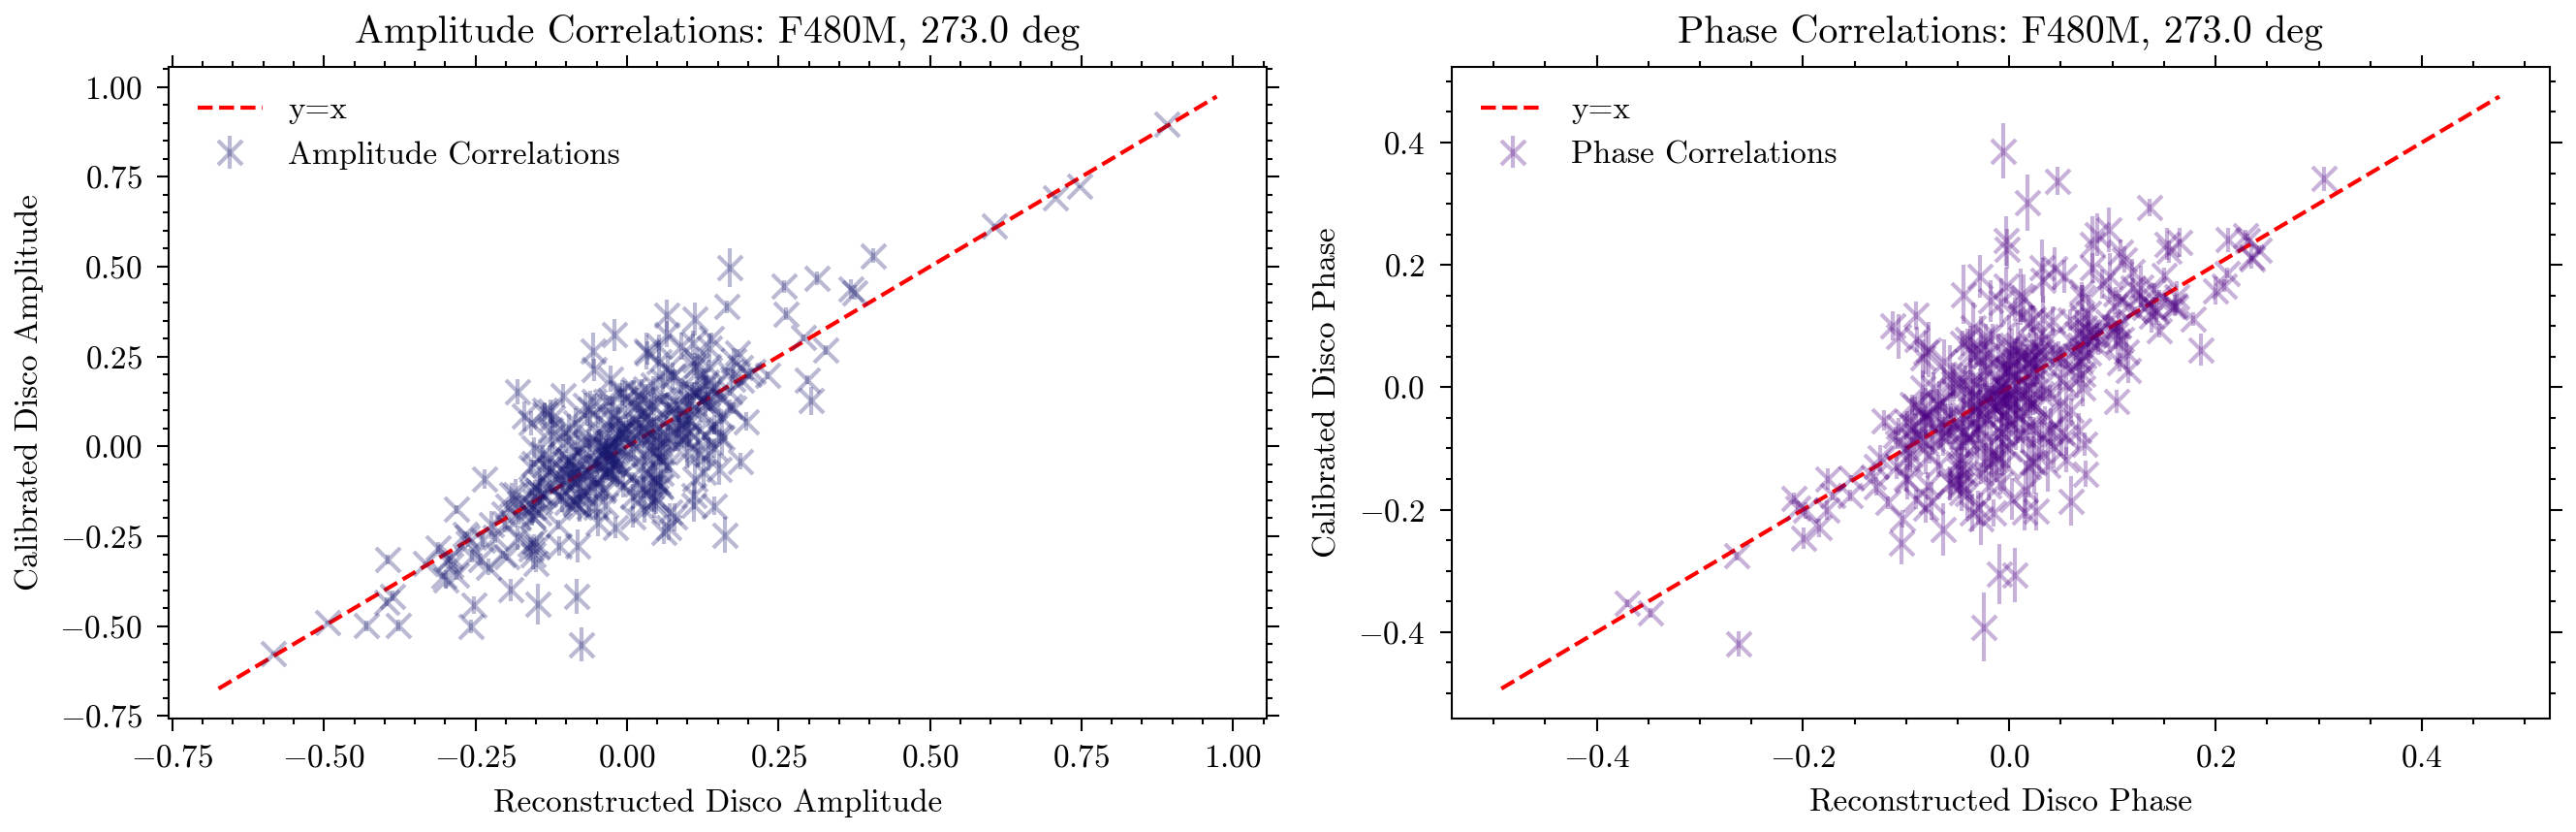

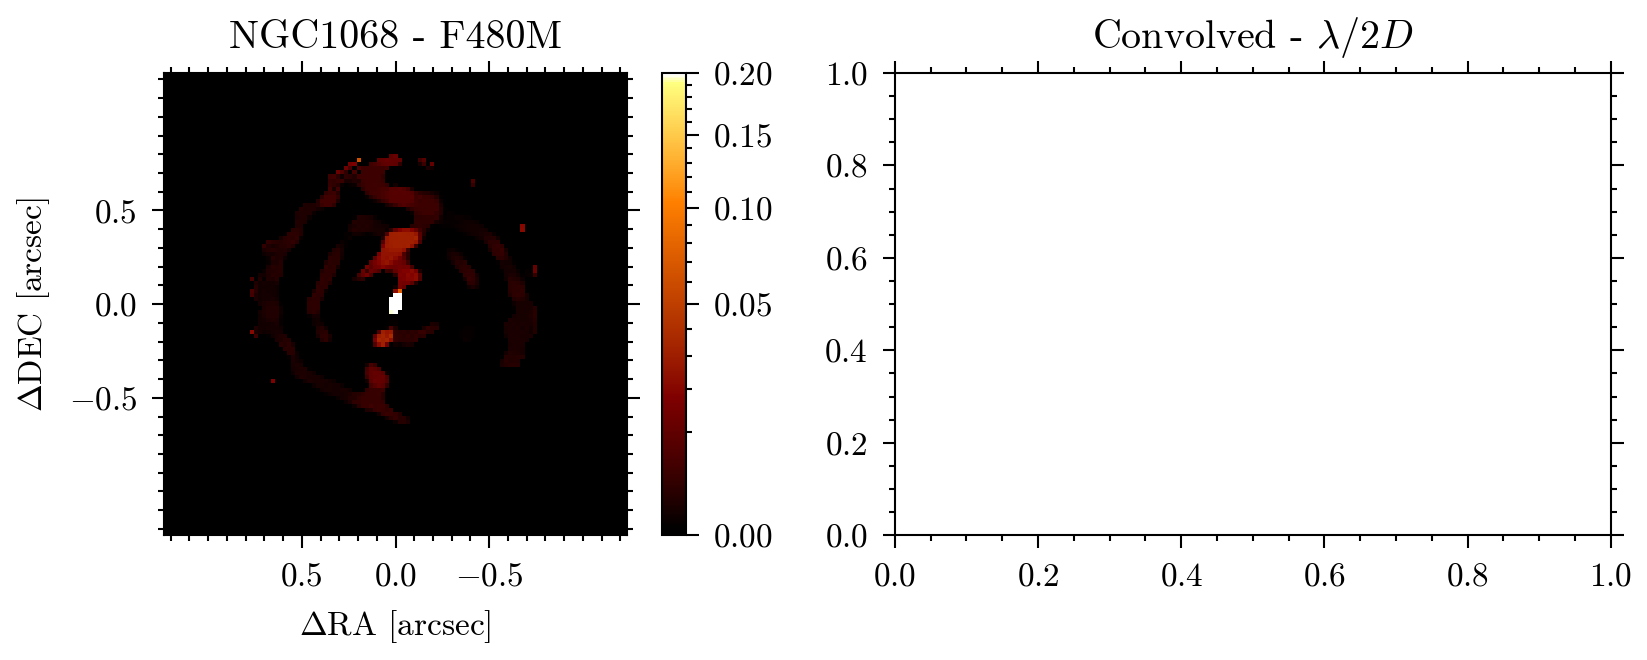

In [19]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    # print(phase_centre(bfgs_model, oi))
    loss = dorito.stats.disco_regularised_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Disco Amplitude")
    ax[0].set_ylabel("Calibrated Disco Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Disco Phase")
    ax[1].set_ylabel("Calibrated Disco Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist / dist.max(),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=0.2),
    )

    # c1 = dorito.plotting.plot_result(
    #     ax[1],
    #     blur_distribution(dist, model, oi, factor=0.5),
    #     pixel_scale=dlu.rad2arcsec(model.pscale_in),
    #     cmap="afmhot_u",
    #     power=0.5,
    #     vmin=None,
    # )
    # fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]

    ax[0].set_title(
        f"NGC1068 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    plt.show()

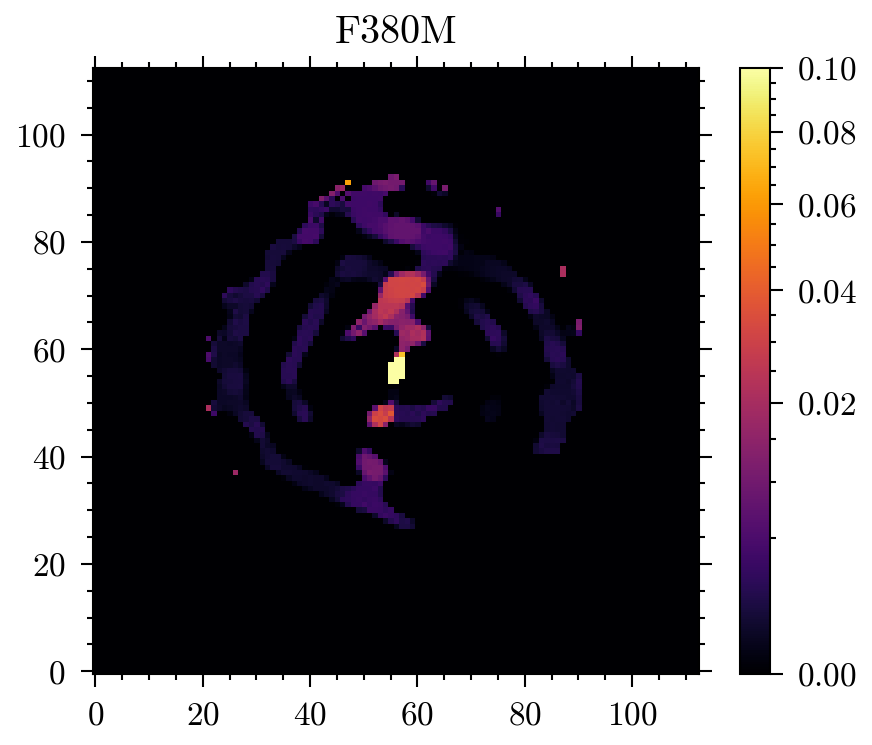

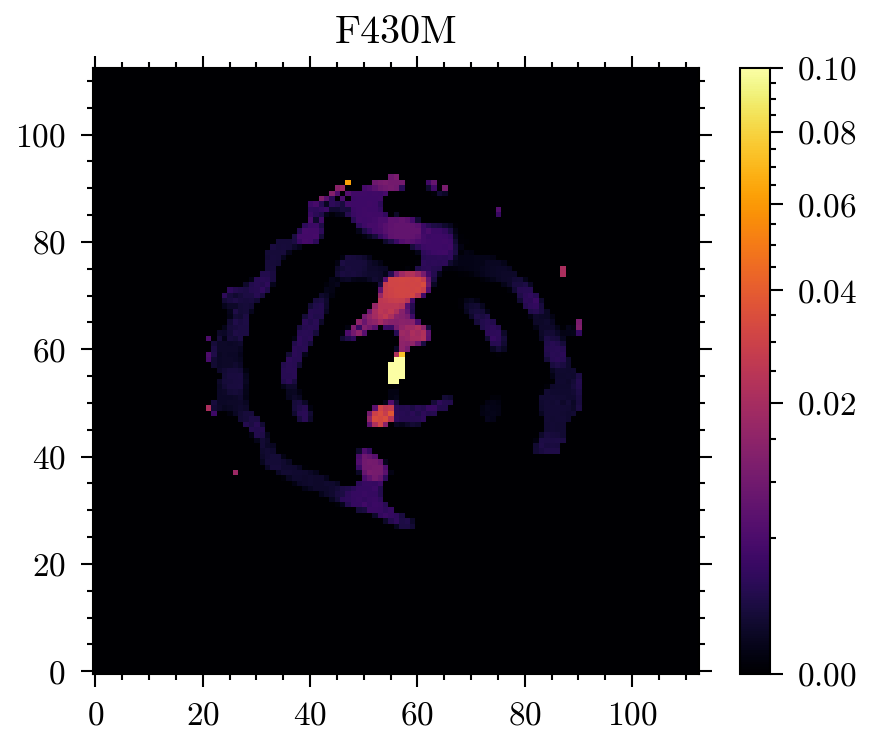

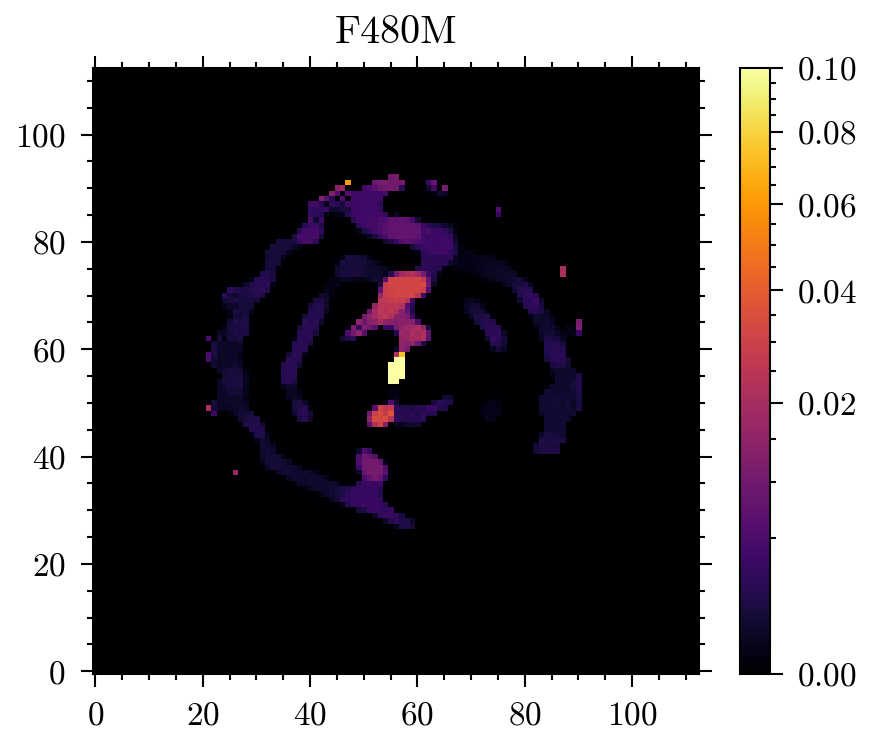

In [20]:
for filt in ["F380M", "F430M", "F480M"]:
    dist = bfgs_model.get_distribution(oi, rotate=False)

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()

    plt.imshow(rl_dist, norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=1e-1))
    plt.title(filt)
    plt.colorbar()
    plt.show()